In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import unicodedata
import matplotlib.font_manager as fm

In [9]:
#한글 폰트
font_path = 'NotoSansKR-Regular.ttf'
fontprop = fm.FontProperties(fname=font_path)
plt.rc('font', family=fontprop.get_name())

In [10]:
#데이터 경로 설정
base_folder = '/Users/limtae-kyu/data-analysis'
folders = ['광야', '돌산', '돔구장', '돔자연짬', '말미잘', '오아시스', '옹기종기', '유적지', '철탑', '터널']

In [11]:
#데이터 불러오기
all_data = []
max_depths = []
for folder in folders:
    folder_path = os.path.join(base_folder, folder)
    if os.path.isdir(folder_path):
        for filename in os.listdir(folder_path):
            if filename.endswith('.csv'):
                file_path = os.path.join(folder_path, filename)

                # 첫 두 행을 별도로 읽기
                with open(file_path, 'r') as file:
                    first_two_lines = [file.readline().strip() for _ in range(2)]
                    print(f"{filename} 설명 행: {first_two_lines}")
                # 세 번째 행부터 데이터 읽기
                df = pd.read_csv(file_path, skiprows=2)
                all_data.append(df)

                # Max Depth 찾기
                possible_columns = ['Max Depth', 'Depth', 'Maximum Depth']
                max_depth_column = next((col for col in possible_columns if col in df.columns), None)
                if max_depth_column:
                    max_depth = df[max_depth_column].max()
                    max_depths.append((filename, max_depth))
                    print(f"{filename}의 최대 깊이: {max_depth}")


#133 2024-8-2 12-15-6-광야.csv 설명 행: ['Dive Number,GF Minimum,GF Maximum,Surface Interval (min),Imperial Units,Start Battery Voltage,Start CNS %,Start Date,Start External O2 Sensor Status,Start Low Set Point,Start High Set Point,Computer Firmware Version,Max Depth,Max Time,Error History,End Battery Voltage,End CNS,End Date,End External O2 Sensor Status,End Low Set Point,End High Set Point,Computer Serial Number,Computer Firmware Version,Computer Model,Log Version,Deco Model,VPM-B Conservatism,Start Surface Pressure,End Surface Pressure,Product', '133,40,85,78,False,3.8,0,8/2/2024 12:15:06 PM,False,0,1,86,34.6,1434,,3.8,3,8/2/2024 12:38:55 PM,False,0,1,937B0677,86,2,13,GF,40/85,994,994,Peregrine']
#133 2024-8-2 12-15-6-광야.csv의 최대 깊이: 34.6
#125 2024-7-27 13-55-45-광야.csv 설명 행: ['Dive Number,GF Minimum,GF Maximum,Surface Interval (min),Imperial Units,Start Battery Voltage,Start CNS %,Start Date,Start External O2 Sensor Status,Start Low Set Point,Start High Set Point,Computer Firmware Version

In [12]:
 # Max Depth 찾기
possible_columns = ['Max Depth', 'Depth', 'Maximum Depth']
max_depth_column = next((col for col in possible_columns if col in df.columns), None)
if max_depth_column:
    max_depth = df[max_depth_column].max()
    max_depths.append((filename, max_depth))
else:
    print("null")
# 최대 깊이 정보 요약
if max_depths:
    max_depths_df = pd.DataFrame(max_depths, columns=['Filename', 'Max Depth'])
    pd.set_option('display.max_rows', None)  # 모든 행을 표시하도록 설정
    print(max_depths_df.to_string(index=False))
else:
    print("null")


                        Filename  Max Depth
    #133 2024-8-2 12-15-6-광야.csv  34.600000
  #125 2024-7-27 13-55-45-광야.csv  28.500000
  #104 2024-7-12 11-10-48-돌산.csv   8.800000
  #128 2024-7-28 14-30-24-돌산.csv   5.700000
   #147 2024-8-9 14-15-33-돌산.csv   8.400001
     #94 2024-7-6 9-13-44-돌산.csv   9.400001
   #132 2024-8-2 10-21-27-돌산.csv  10.600000
   #144 2024-8-8 11-50-11-돌산.csv  10.100000
   #135 2024-8-2 15-59-28-돌산.csv   4.500000
  #109 2024-7-13 14-59-55-돌산.csv   9.900001
   #112 2024-7-19 11-2-47-돌산.csv  10.600000
    #88 2024-6-29 9-19-17-돌산.csv  10.300000
  #110 2024-7-13 16-52-22-돌산.csv   8.800000
    #123 2024-7-27 9-19-9-돌산.csv   9.100000
  #164 2024-8-18 11-25-31-돌산.csv   8.900001
    #130 2024-8-1 15-0-56-돌산.csv   9.400001
   #152 2024-8-15 9-16-53-돌산.csv   8.900001
  #159 2024-8-16 15-35-34-돌산.csv   9.400001
  #120 2024-7-26 10-25-19-돌산.csv   8.700000
  #111 2024-7-19 9-31-42-돔구장.csv  17.000000
 #165 2024-8-18 14-46-49-돔구장.csv  22.200000
 #162 2024-8-17 14-11-20-돔구장.csv

In [13]:
# 최대 수심이 깊은 상위 1-10위
if max_depths:
    max_depths_df = pd.DataFrame(max_depths, columns=['Filename', 'Max Depth'])
    top_10_max_depths = max_depths_df.nlargest(10, 'Max Depth')
    print(top_10_max_depths.to_string(index=False))

                       Filename  Max Depth
   #133 2024-8-2 12-15-6-광야.csv       34.6
#116 2024-7-20 11-11-21-말미잘.csv       32.0
 #134 2024-8-2 14-45-19-말미잘.csv       30.0
 #156 2024-8-16 12-51-9-말미잘.csv       30.0
#161 2024-8-17 11-40-23-말미잘.csv       29.0
 #125 2024-7-27 13-55-45-광야.csv       28.5
  #99 2024-7-7 11-43-34-말미잘.csv       28.1
   #140 2024-8-3 12-36-8-철탑.csv       28.0
 #105 2024-7-12 13-44-50-철탑.csv       27.5
 #154 2024-8-16 10-31-55-철탑.csv       27.3


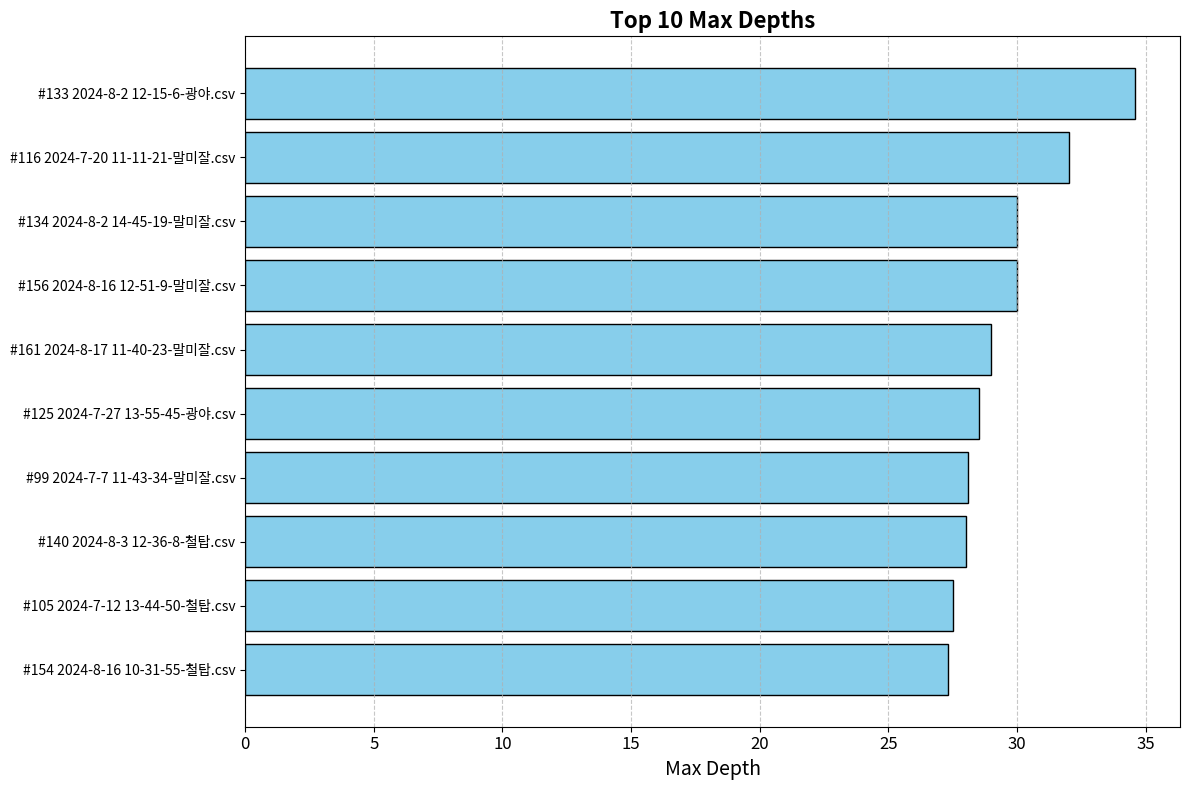

In [15]:
# 시각화 추가
plt.figure(figsize=(12, 8))  # 그래프 크기 조정
plt.barh(top_10_max_depths['Filename'], top_10_max_depths['Max Depth'], color='skyblue', edgecolor='black')
plt.xlabel('Max Depth', fontsize=14)
#plt.ylabel('Filename', fontsize=14)
plt.title('Top 10 Max Depths', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.gca().invert_yaxis()  # 수평 막대그래프에서 큰 값이 위로 오도록 설정
plt.grid(axis='x', linestyle='--', alpha=0.7)  # 가독성을 위한 그리드 추가
plt.tight_layout()
plt.show()
